# **AI-Based Recycling Classification Using CNN**

In [ ]:
# import libraries
from google.colab import drive
import os
import shutil
import random

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define dataset path
source_dir = "/content/drive/MyDrive/Recyclable_Materials4"
output_dir = "/content/drive/MyDrive/Recyclable_Split4"

# Define classes
classes = ['cardboard', 'metal', 'plastic']

# Set random seed for reproducibility
random.seed(42)

Mounted at /content/drive


In [ ]:
# Remove old split if exists
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

# Create folders
for split in ["train", "val", "test"]:
    for class_name in classes:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# Process each class
for class_name in classes:
    class_path = os.path.join(source_dir, class_name)

    images = []

    # Get image paths
    for item in os.listdir(class_path):
        item_path = os.path.join(class_path, item)

        if os.path.isfile(item_path):
            images.append(item_path)

    # Shuffle
    random.shuffle(images)

    # Split
    total = len(images)
    train_end = int(total * 0.7)
    val_end = train_end + int(total * 0.15)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy train
    for img_path in train_imgs:
        shutil.copy(
            img_path,
            os.path.join(output_dir, "train", class_name, os.path.basename(img_path))
        )

    # Copy val
    for img_path in val_imgs:
        shutil.copy(
            img_path,
            os.path.join(output_dir, "val", class_name, os.path.basename(img_path))
        )

    # Copy test
    for img_path in test_imgs:
        shutil.copy(
            img_path,
            os.path.join(output_dir, "test", class_name, os.path.basename(img_path))
        )


In [ ]:
# Load datasets (Train / Val / Test)

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Dataset paths
TRAIN_PATH = "/content/drive/MyDrive/Recyclable_Split4/train"
VAL_PATH   = "/content/drive/MyDrive/Recyclable_Split4/val"
TEST_PATH  = "/content/drive/MyDrive/Recyclable_Split4/test"

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 906 files belonging to 3 classes.
Found 193 files belonging to 3 classes.
Found 196 files belonging to 3 classes.


In [ ]:
class_names = train_dataset.class_names
print(class_names)

['cardboard', 'metal', 'plastic']


In [ ]:
# Optimize dataset performance using caching and prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Data augmentation to improve model generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.3)
])

In [ ]:
# Build CNN model
model = models.Sequential()

# Input layer + augmentation + normalization
model.add(layers.Input(shape=(224, 224, 3)))
model.add(data_augmentation)
model.add(layers.Rescaling(1./255))



# Convolutional blocks (feature extraction)
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# Flatten features
model.add(layers.Flatten())

# Fully connected layers
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))


model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Fully connected layers
model.add(layers.Dense(3, activation='softmax'))

In [ ]:
# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.0001
)

In [ ]:
# Stop training early if model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
# Compile the model by defining optimizer, loss function, and evaluation metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the CNN model with validation and callbacks
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.5927 - loss: 7.6748 - val_accuracy: 0.3834 - val_loss: 2.6974 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.6225 - loss: 7.3035 - val_accuracy: 0.2176 - val_loss: 4.8100 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.6159 - loss: 6.1739 - val_accuracy: 0.3731 - val_loss: 4.0356 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.6369 - loss: 5.6645 - val_accuracy: 0.3731 - val_loss: 9.7259 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.6755 - loss: 4.3470 - val_accuracy: 0.3161 - val_loss: 5.5758 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.6247 - loss: 3.4115 - val_accuracy: 0.4041 - val_loss: 3.9790 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.6954 - loss: 2.6643 -

In [ ]:
# Evaluate the model on test data to measure final performance
test_loss, test_acc = model.evaluate(test_dataset)

# Print accuracy and loss results
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.8622 - loss: 0.4231
Test Accuracy: 0.8622449040412903
Test Loss: 0.42313820123672485


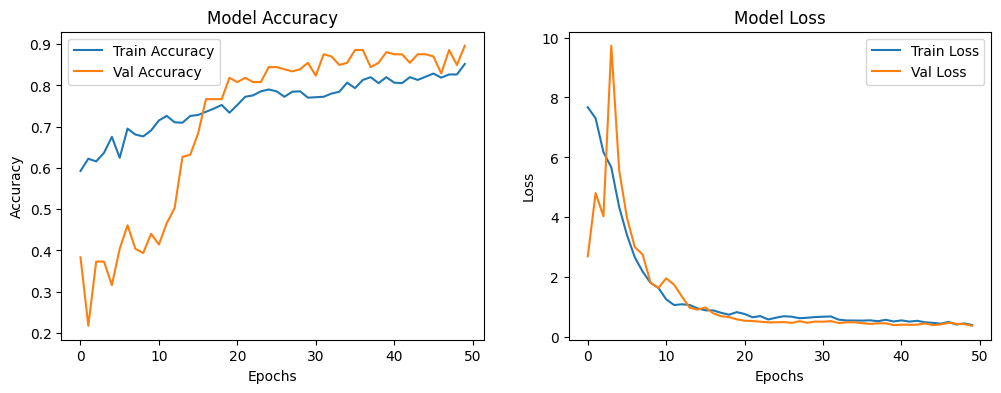

In [ ]:
#Accuracy Curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate model using Precision, Recall, and F1-score
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.95      0.85      0.90        61
       metal       0.79      0.87      0.83        62
     plastic       0.86      0.86      0.86        73

    accuracy                           0.86       196
   macro avg       0.87      0.86      0.86       196
weighted avg       0.87      0.86      0.86       196



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


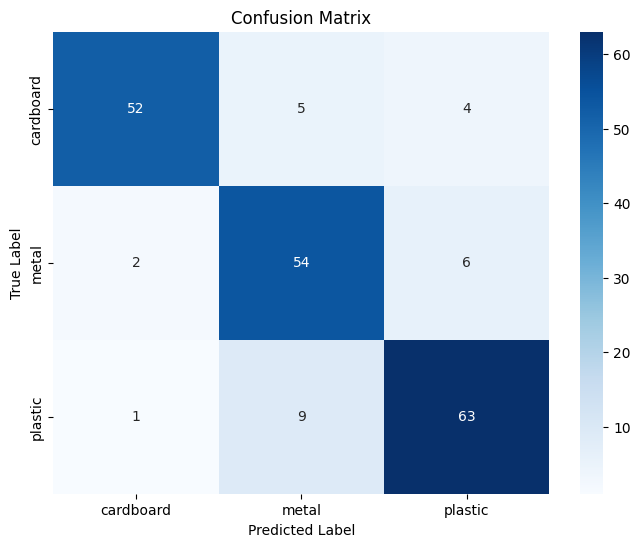

In [ ]:
# Evaluate the model using a confusion matrix for each class
y_pred = []
y_true = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Create the file with the new name
model.save('AI_Recycling_CNN_Model6.keras')

In [ ]:
# Load the trained CNN model
model = tf.keras.models.load_model('/content/drive/MyDrive/AI_Recycling_CNN_Model6.keras')